1. EDA

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [104]:
df=pd.read_csv('C:/Users/kousu/Desktop/Breast_Cancer/SEER Breast Cancer Dataset .csv')

In [105]:
df.head()

,Age,Race,Marital Status,Unnamed: 3,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,43,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N3,IIIC,Moderately differentiated; Grade II,Regional,40,Positive,Positive,19,11,1,Alive
1,47,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,45,Positive,Positive,25,9,2,Alive
2,67,White,Married (including common law),NaN,T2,N1,IIB,Poorly differentiated; Grade III,Regional,25,Positive,Positive,4,1,2,Dead
3,46,White,Divorced,NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,19,Positive,Positive,26,1,2,Dead
4,63,White,Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,35,Positive,Positive,21,5,3,Dead


In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     4024 non-null   int64  
 1   Race                    4024 non-null   str    
 2   Marital Status          4024 non-null   str    
 3   Unnamed: 3              0 non-null      float64
 4   T Stage                 4024 non-null   str    
 5   N Stage                 4024 non-null   str    
 6   6th Stage               4024 non-null   str    
 7   Grade                   4024 non-null   str    
 8   A Stage                 4024 non-null   str    
 9   Tumor Size              4024 non-null   int64  
 10  Estrogen Status         4024 non-null   str    
 11  Progesterone Status     4024 non-null   str    
 12  Regional Node Examined  4024 non-null   int64  
 13  Reginol Node Positive   4024 non-null   int64  
 14  Survival Months         4024 non-null   int64  
 15

In [107]:
df.describe()

,Age,Unnamed: 3,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months
count,4024.000000,0.0,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,NaN,30.473658,14.357107,4.158052,71.297962
std,8.963134,NaN,21.119696,8.099675,5.109331,22.921430
min,30.000000,NaN,1.000000,1.000000,1.000000,1.000000
25%,47.000000,NaN,16.000000,9.000000,1.000000,56.000000
50%,54.000000,NaN,25.000000,14.000000,2.000000,73.000000
75%,61.000000,NaN,38.000000,19.000000,5.000000,90.000000
max,69.000000,NaN,140.000000,61.000000,46.000000,107.000000


In [108]:
df.shape

(4024, 16)

2. Preprocessing


In [109]:
#handle duplicate data
df.duplicated().sum()

np.int64(1)

In [110]:
#drop duplicate(s)
df.drop_duplicates()

,Age,Race,Marital Status,Unnamed: 3,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,43,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N3,IIIC,Moderately differentiated; Grade II,Regional,40,Positive,Positive,19,11,1,Alive
1,47,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,45,Positive,Positive,25,9,2,Alive
2,67,White,Married (including common law),NaN,T2,N1,IIB,Poorly differentiated; Grade III,Regional,25,Positive,Positive,4,1,2,Dead
3,46,White,Divorced,NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,19,Positive,Positive,26,1,2,Dead
4,63,White,Married (including common law),NaN,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,35,Positive,Positive,21,5,3,Dead
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,52,White,Married (including common law),NaN,T1,N1,IIA,Well differentiated; Grade I,Regional,10,Positive,Positive,19,1,107,Alive
4020,53,White,Married (including common law),NaN,T1,N2,IIIA,Poorly differentiated; Grade III,Regional,9,Negative,Negative,13,5,107,Alive
4021,53,White,Divorced,NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,9,Negative,Negative,4,2,107,Alive
4022,60,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),NaN,T1,N1,IIA,Moderately differentiated; Grade II,Regional,9,Positive,Positive,14,2,107,Alive


In [111]:
df.isnull().sum()

Age                          0
Race                         0
Marital Status               0
Unnamed: 3                4024
T Stage                      0
N Stage                      0
6th Stage                    0
Grade                        0
A Stage                      0
Tumor Size                   0
Estrogen Status              0
Progesterone Status          0
Regional Node Examined       0
Reginol Node Positive        0
Survival Months              0
Status                       0
dtype: int64

In [112]:
#drop unnamed column
df.drop(['Unnamed: 3'], axis=1, inplace=True)

In [113]:
#grade= grade of tumour
#n stage= no of nymph nodes
#6th stage=overall stage of cancer
#grade =grade of cancer
#a stage= distant metastasis status

In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Age                     4024 non-null   int64
 1   Race                    4024 non-null   str  
 2   Marital Status          4024 non-null   str  
 3   T Stage                 4024 non-null   str  
 4   N Stage                 4024 non-null   str  
 5   6th Stage               4024 non-null   str  
 6   Grade                   4024 non-null   str  
 7   A Stage                 4024 non-null   str  
 8   Tumor Size              4024 non-null   int64
 9   Estrogen Status         4024 non-null   str  
 10  Progesterone Status     4024 non-null   str  
 11  Regional Node Examined  4024 non-null   int64
 12  Reginol Node Positive   4024 non-null   int64
 13  Survival Months         4024 non-null   int64
 14  Status                  4024 non-null   str  
dtypes: int64(5), str(10)
memory usag

In [115]:
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,43,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),T2,N3,IIIC,Moderately differentiated; Grade II,Regional,40,Positive,Positive,19,11,1,Alive
1,47,"Other (American Indian/AK Native, Asian/Pacifi...",Married (including common law),T2,N2,IIIA,Moderately differentiated; Grade II,Regional,45,Positive,Positive,25,9,2,Alive
2,67,White,Married (including common law),T2,N1,IIB,Poorly differentiated; Grade III,Regional,25,Positive,Positive,4,1,2,Dead
3,46,White,Divorced,T1,N1,IIA,Moderately differentiated; Grade II,Regional,19,Positive,Positive,26,1,2,Dead
4,63,White,Married (including common law),T2,N2,IIIA,Moderately differentiated; Grade II,Regional,35,Positive,Positive,21,5,3,Dead


In [116]:
df['Grade'].unique()

<ArrowStringArray>
[   'Moderately differentiated; Grade II',
       'Poorly differentiated; Grade III',
           'Well differentiated; Grade I',
 'Undifferentiated; anaplastic; Grade IV']
Length: 4, dtype: str

In [117]:
#unique values in marital status
df['Marital Status'].unique()

<ArrowStringArray>
['Married (including common law)',                       'Divorced',
         'Single (never married)',                        'Widowed',
                      'Separated']
Length: 5, dtype: str

In [118]:
df.shape

(4024, 15)

In [119]:
#encoding using one hot encodingO(0,1)
df_encoded = pd.get_dummies(df, columns=['Marital Status'], drop_first=False, dtype=int)
df_encoded.head()


,Age,Race,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status,Marital Status_Divorced,Marital Status_Married (including common law),Marital Status_Separated,Marital Status_Single (never married),Marital Status_Widowed
0,43,"Other (American Indian/AK Native, Asian/Pacifi...",T2,N3,IIIC,Moderately differentiated; Grade II,Regional,40,Positive,Positive,19,11,1,Alive,0,1,0,0,0
1,47,"Other (American Indian/AK Native, Asian/Pacifi...",T2,N2,IIIA,Moderately differentiated; Grade II,Regional,45,Positive,Positive,25,9,2,Alive,0,1,0,0,0
2,67,White,T2,N1,IIB,Poorly differentiated; Grade III,Regional,25,Positive,Positive,4,1,2,Dead,0,1,0,0,0
3,46,White,T1,N1,IIA,Moderately differentiated; Grade II,Regional,19,Positive,Positive,26,1,2,Dead,1,0,0,0,0
4,63,White,T2,N2,IIIA,Moderately differentiated; Grade II,Regional,35,Positive,Positive,21,5,3,Dead,0,1,0,0,0


In [120]:
print(df_encoded.columns)


Index(['Age', 'Race ', 'T Stage ', 'N Stage', '6th Stage', 'Grade', 'A Stage',
       'Tumor Size', 'Estrogen Status', 'Progesterone Status',
       'Regional Node Examined', 'Reginol Node Positive', 'Survival Months',
       'Status', 'Marital Status_Divorced',
       'Marital Status_Married (including common law)',
       'Marital Status_Separated', 'Marital Status_Single (never married)',
       'Marital Status_Widowed'],
      dtype='str')


In [121]:
#encoding T Stage, T1, T2, T3, T4 using label encoding (0,1,2,3)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_encoded['T Stage '] = le.fit_transform(df_encoded['T Stage '])
df_encoded.head()


,Age,Race,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status,Marital Status_Divorced,Marital Status_Married (including common law),Marital Status_Separated,Marital Status_Single (never married),Marital Status_Widowed
0,43,"Other (American Indian/AK Native, Asian/Pacifi...",1,N3,IIIC,Moderately differentiated; Grade II,Regional,40,Positive,Positive,19,11,1,Alive,0,1,0,0,0
1,47,"Other (American Indian/AK Native, Asian/Pacifi...",1,N2,IIIA,Moderately differentiated; Grade II,Regional,45,Positive,Positive,25,9,2,Alive,0,1,0,0,0
2,67,White,1,N1,IIB,Poorly differentiated; Grade III,Regional,25,Positive,Positive,4,1,2,Dead,0,1,0,0,0
3,46,White,0,N1,IIA,Moderately differentiated; Grade II,Regional,19,Positive,Positive,26,1,2,Dead,1,0,0,0,0
4,63,White,1,N2,IIIA,Moderately differentiated; Grade II,Regional,35,Positive,Positive,21,5,3,Dead,0,1,0,0,0


In [122]:
#encoding N Stage, N0, N1, N2, N3 using label encoding (0,1,2,3)
df_encoded['N Stage'] = le.fit_transform(df_encoded['N Stage'])

In [123]:
#unique values in 6th stage
df_encoded['6th Stage'].unique()

<ArrowStringArray>
['IIIC', 'IIIA', 'IIB', 'IIA', 'IIIB']
Length: 5, dtype: str

In [124]:
#encoding 6th Stage,['IIIC', 'IIIA', 'IIB', 'IIA', 'IIIB'] using label encoding (0,1,2,3,4)'
df_encoded['6th Stage'] = le.fit_transform(df_encoded['6th Stage'])

In [125]:
#value count of A stage
df_encoded['A Stage'].value_counts()

A Stage
Regional    3932
Distant       92
Name: count, dtype: int64

In [126]:
#encode A stage using label encoding regional =0, distant=1
df_encoded['A Stage'] = le.fit_transform(df_encoded['A Stage']) 
df_encoded.head()

,Age,Race,T Stage,N Stage,6th Stage,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status,Marital Status_Divorced,Marital Status_Married (including common law),Marital Status_Separated,Marital Status_Single (never married),Marital Status_Widowed
0,43,"Other (American Indian/AK Native, Asian/Pacifi...",1,2,4,Moderately differentiated; Grade II,1,40,Positive,Positive,19,11,1,Alive,0,1,0,0,0
1,47,"Other (American Indian/AK Native, Asian/Pacifi...",1,1,2,Moderately differentiated; Grade II,1,45,Positive,Positive,25,9,2,Alive,0,1,0,0,0
2,67,White,1,0,1,Poorly differentiated; Grade III,1,25,Positive,Positive,4,1,2,Dead,0,1,0,0,0
3,46,White,0,0,0,Moderately differentiated; Grade II,1,19,Positive,Positive,26,1,2,Dead,1,0,0,0,0
4,63,White,1,1,2,Moderately differentiated; Grade II,1,35,Positive,Positive,21,5,3,Dead,0,1,0,0,0


In [127]:
#value count of estrogen status
df_encoded['Estrogen Status'].value_counts()

Estrogen Status
Positive    3755
Negative     269
Name: count, dtype: int64

In [128]:
#encode estrogen status using label encoding (0,1)
df_encoded['Estrogen Status'] = le.fit_transform(df_encoded['Estrogen Status'])

In [129]:
df_encoded['Progesterone Status'].value_counts()

Progesterone Status
Positive    3326
Negative     698
Name: count, dtype: int64

In [130]:
#encode progesterone status using label encoding (0,1)
df_encoded['Progesterone Status'] = le.fit_transform(df_encoded['Progesterone Status'])

In [131]:
# encoding 'Moderately differentiated; Grade II','Poorly differentiated; Grade III','Well differentiated; Grade I', 'Undifferentiated; anaplastic; Grade IV'
grade_mapping = {
    'Moderately differentiated; Grade II': 2,
    'Poorly differentiated; Grade III': 1,
    'Well differentiated; Grade I': 3,
    'Undifferentiated; anaplastic; Grade IV': 0
}
df_encoded['Grade'] = df_encoded['Grade'].map(grade_mapping)


In [132]:
#encode race using one hot encoding
df_encoded = pd.get_dummies(df_encoded, columns=['Race '], drop_first=False, dtype=int)

In [133]:
#encode status(alive=1, dead=0)
df_encoded['Status'] = le.fit_transform(df_encoded['Status'])
print(df_encoded.head())

   Age  T Stage   N Stage  6th Stage  Grade  A Stage  Tumor Size  \
0   43         1        2          4      2        1          40   
1   47         1        1          2      2        1          45   
2   67         1        0          1      1        1          25   
3   46         0        0          0      2        1          19   
4   63         1        1          2      2        1          35   

   Estrogen Status  Progesterone Status  Regional Node Examined  ...  \
0                1                    1                      19  ...   
1                1                    1                      25  ...   
2                1                    1                       4  ...   
3                1                    1                      26  ...   
4                1                    1                      21  ...   

   Survival Months  Status  Marital Status_Divorced  \
0                1       0                        0   
1                2       0                      

3. Feature selection and engineering


In [134]:
#separete featutred and target
X=df_encoded.drop('Status', axis=1)
y=df_encoded['Status']   


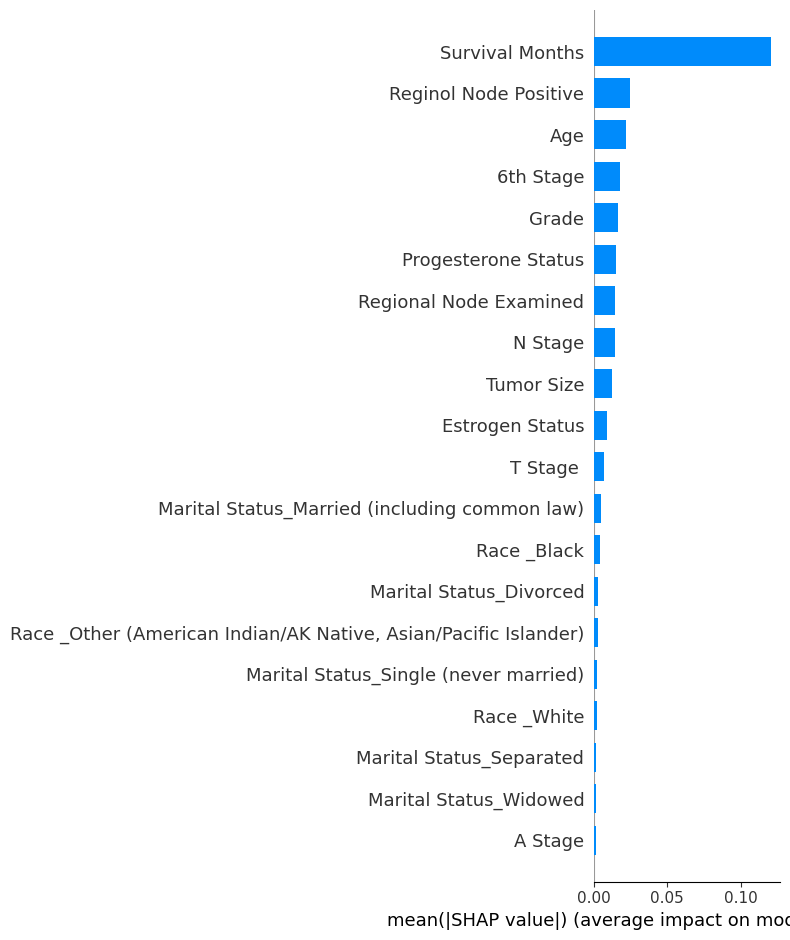

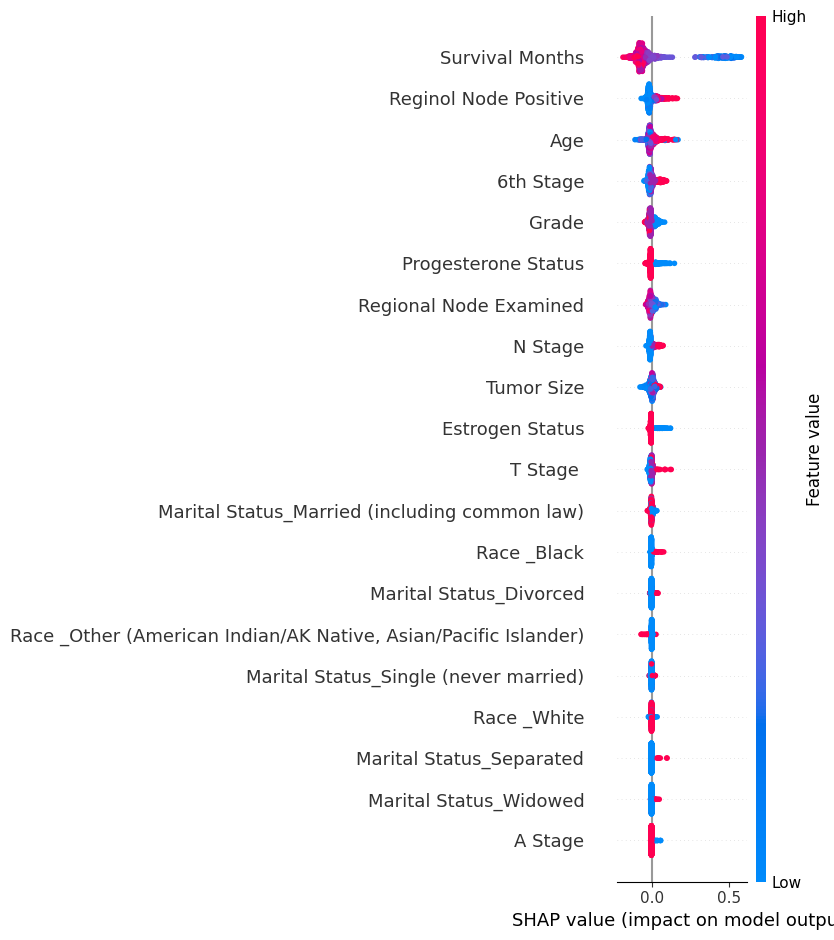

In [135]:
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Train-test split (important for realistic explanation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values on test set
shap_values = explainer.shap_values(X_test)

# Ensure shap_values has shape (n_classes, n_samples, n_features) or is a list of arrays per class.
# Different SHAP versions / models may return shapes like (n_samples, n_features, n_classes).
# Handle both cases and select class 1 explanations for binary classification.
import numpy as _np  # relies on numpy already imported elsewhere in the notebook; alias local to avoid shadowing
if isinstance(shap_values, list):
    # typical case: list of arrays, one per class
    shap_values_class1 = shap_values[1]
else:
    arr = _np.array(shap_values)
    if arr.ndim == 3:
        # if first axis equals n_samples, transpose to (n_classes, n_samples, n_features)
        if arr.shape[0] == X_test.shape[0]:
            arr = _np.transpose(arr, (2, 0, 1))
        # now arr should be (n_classes, n_samples, n_features)
        # guard: if only one class available fallback to 0
        class_index = 1 if arr.shape[0] > 1 else 0
        shap_values_class1 = arr[class_index]
    else:
        # fallback: already 2D
        shap_values_class1 = arr

# Bar summary plot (feature importance)
shap.summary_plot(
    shap_values_class1,
    X_test,
    plot_type="bar"
)

# Detailed beeswarm plot
shap.summary_plot(
    shap_values_class1,
    X_test
)


In [136]:
df_encoded.columns

Index(['Age', 'T Stage ', 'N Stage', '6th Stage', 'Grade', 'A Stage',
       'Tumor Size', 'Estrogen Status', 'Progesterone Status',
       'Regional Node Examined', 'Reginol Node Positive', 'Survival Months',
       'Status', 'Marital Status_Divorced',
       'Marital Status_Married (including common law)',
       'Marital Status_Separated', 'Marital Status_Single (never married)',
       'Marital Status_Widowed', 'Race _Black',
       'Race _Other (American Indian/AK Native, Asian/Pacific Islander)',
       'Race _White'],
      dtype='str')

In [137]:
#drop Marital Status_Married, Marital Status_Single, Marital Status_Widowed, Marital Status_Divorced, Marital Status_Separated, Race_white, Race_black, Race_Other()
X = X.drop(columns=[
    'Marital Status_Married (including common law)', 'Marital Status_Single (never married)', 'Marital Status_Widowed',
    'Marital Status_Divorced', 'Marital Status_Separated',
    'Race _White', 'Race _Black', 'Race _Other (American Indian/AK Native, Asian/Pacific Islander)'
])

4. Models


In [138]:
#logistic regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.97      0.93       672
           1       0.74      0.44      0.55       133

    accuracy                           0.88       805
   macro avg       0.82      0.71      0.74       805
weighted avg       0.87      0.88      0.87       805

[[651  21]
 [ 74  59]]


In [139]:
#logistic regression with hyperparameter tuning using GridSearchCV and 5 fold cross validation
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)
print("Best Hyperparameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Hyperparameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       672
           1       0.75      0.44      0.56       133

    accuracy                           0.88       805
   macro avg       0.82      0.71      0.74       805
weighted avg       0.87      0.88      0.87       805

[[652  20]
 [ 74  59]]


c:\Users\kousu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kousu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [140]:
#randomForest 
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.92      0.97      0.95       672
           1       0.79      0.59      0.68       133

    accuracy                           0.91       805
   macro avg       0.86      0.78      0.81       805
weighted avg       0.90      0.91      0.90       805

[[651  21]
 [ 54  79]]


In [141]:
#randomForest with hyperparameter tuning using GridSearchCV and 5 fold cross validation
from sklearn.model_selection import GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_search_rf.fit(X_train, y_train)
print("Best Hyperparameters for Random Forest:", grid_search_rf.best_params_)
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf_best = best_rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf_best))
print(confusion_matrix(y_test, y_pred_rf_best)) 


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Hyperparameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       672
           1       0.81      0.59      0.68       133

    accuracy                           0.91       805
   macro avg       0.87      0.78      0.81       805
weighted avg       0.90      0.91      0.90       805

[[654  18]
 [ 55  78]]


In [142]:
#lightgbm
import lightgbm as lgb
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
print(classification_report(y_test, y_pred_lgb))
print(confusion_matrix(y_test, y_pred_lgb))


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 483, number of negative: 2736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001208 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 333
[LightGBM] [Info] Number of data points in the train set: 3219, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.150047 -> initscore=-1.734236
[LightGBM] [Info] Start training from score -1.734236
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       672
           1       0.80      0.57      0.67       133

    accuracy                           0.91       805
   macro avg       0.86      0.77      0.81       805
weighted avg       0.90      0.91      0.90       805

[[653  19]
 [ 57  76]]


In [143]:
#lightgbm using hyperparameter tuning with GridSearchCV and 5 fold cross validation
from sklearn.model_selection import GridSearchCV
param_grid_lgb = {
    'num_leaves': [31, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}
grid_search_lgb = GridSearchCV(
    estimator=lgb.LGBMClassifier(random_state=42),
    param_grid=param_grid_lgb,
    cv=5,
    n_jobs=-1,
    verbose=2,
    refit=True
)
grid_search_lgb.fit(X_train, y_train)
print("Best Hyperparameters for LightGBM:", grid_search_lgb.best_params_)
best_lgb_model = grid_search_lgb.best_estimator_
y_pred_lgb_best = best_lgb_model.predict(X_test)
print(classification_report(y_test, y_pred_lgb_best))
print(confusion_matrix(y_test, y_pred_lgb_best))


Fitting 5 folds for each of 27 candidates, totalling 135 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 483, number of negative: 2736
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000347 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 333
[LightGBM] [Info] Number of data points in the train set: 3219, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.150047 -> initscore=-1.734236
[LightGBM] [Info] Start training from score -1.734236
Best Hyperparameters for LightGBM: {'learning_rate': 0.01, 'n_estimators': 200, 'num_leaves': 31}
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       672
           1       0.82      0.56      0.66       133

    accuracy                           0.91

Best Model: Lightgbm

In [144]:
#pickle the best model
import pickle
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_lgb_model, f)

        